# 🔍 Support Integrity Auditor (SIA)
### MARS Open Projects 2026 — AI/ML Track
**Detecting Priority Mismatch in Customer Support Tickets via Self-Supervised Pseudo-Labeling**

---
**Pipeline Overview:**
1. 📦 Setup & Data Loading  
2. 📊 Exploratory Data Analysis (EDA)  
3. 🧹 Text Preprocessing  
4. 🏷️ Stage 1 — Pseudo-Label Generation (4-Signal Ensemble)  
5. 📉 Ablation Study  
6. 🤖 Stage 2 — Supervised Classifier (Baseline + DeBERTa Fine-Tune)  
7. 📋 Stage 3 — Evidence Dossier Generation  
8. ⚔️ Adversarial Robustness Testing  
9. 💾 Model Saving  
10. 🚀 Streamlit App Export  
11. 📐 Final Deliverables  


## 📦 Cell 1 — Install Dependencies
Install all required libraries. Run once per Colab session.

In [ ]:
# Install all required packages for SIA pipeline
!pip install -q sentence-transformers transformers torch torchvision torchaudio
!pip install -q xgboost imbalanced-learn shap wordcloud plotly streamlit
!pip install -q accelerate datasets evaluate scikit-learn pandas numpy
print("✅ All packages installed successfully.")


## 📦 Cell 2 — Global Imports

In [1]:
# ── Standard Library ──────────────────────────────────────────────
import os, re, json, warnings, random, time
from pathlib import Path
from datetime import datetime
from collections import Counter

warnings.filterwarnings("ignore")

# ── Data Science ──────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# ── NLP / Text ────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# ── Deep Learning ─────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    pipeline as hf_pipeline
)
from sentence_transformers import SentenceTransformer

# ── GPU Check ─────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Reproducibility ───────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("✅ All imports successful.")


🖥️  Device: CUDA
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ All imports successful.


## ☁️ Cell 3 — Mount Google Drive & Load Dataset

In [3]:
# Mount Google Drive to access dataset
from google.colab import drive
drive.mount('/content/drive')

# ── Dataset path ──────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/MARS SIA OP/customer_support_tickets.csv"
OUTPUT_DIR = "/content/drive/MyDrive/SIA_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📂 Output directory: {OUTPUT_DIR}")


Mounted at /content/drive
📂 Output directory: /content/drive/MyDrive/SIA_outputs


## 📂 Cell 4 — Load & Inspect Dataset

In [4]:
# ── Load CSV ──────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

print("=" * 55)
print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
print("\n📋 Columns & Data Types:")
print(df.dtypes.to_string())

print("\n🔍 First 3 Rows:")
display(df.head(3))

print("\n❓ Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "  ✅ No missing values")

print("\n🔁 Duplicate Rows:", df.duplicated().sum())

print("\n📊 Numerical Summary:")
display(df.describe())

# ── Priority class distribution ───────────────────────────────────
print("\n🏷️  Priority_Level Distribution:")
print(df['Priority_Level'].value_counts())


📊 Dataset Shape: 20,000 rows × 12 columns

📋 Columns & Data Types:
Ticket_ID                object
Customer_Name            object
Customer_Email           object
Ticket_Subject           object
Ticket_Description       object
Issue_Category           object
Priority_Level           object
Ticket_Channel           object
Submission_Date          object
Resolution_Time_Hours     int64
Assigned_Agent           object
Satisfaction_Score        int64

🔍 First 3 Rows:


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5



❓ Missing Values:
  ✅ No missing values

🔁 Duplicate Rows: 0

📊 Numerical Summary:


,Resolution_Time_Hours,Satisfaction_Score
count,20000.000000,20000.000000
mean,39.230300,3.723700
std,35.221884,1.286989
min,1.000000,1.000000
25%,11.000000,3.000000
50%,27.000000,4.000000
75%,58.000000,5.000000
max,120.000000,5.000000



🏷️  Priority_Level Distribution:
Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64


## 📊 Cell 5 — Exploratory Data Analysis (EDA)
Comprehensive visual exploration of the dataset covering class distributions, resolution time, satisfaction scores, ticket channels, and text characteristics.

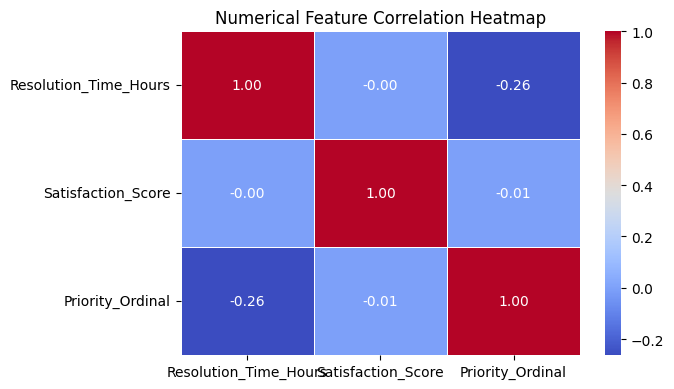

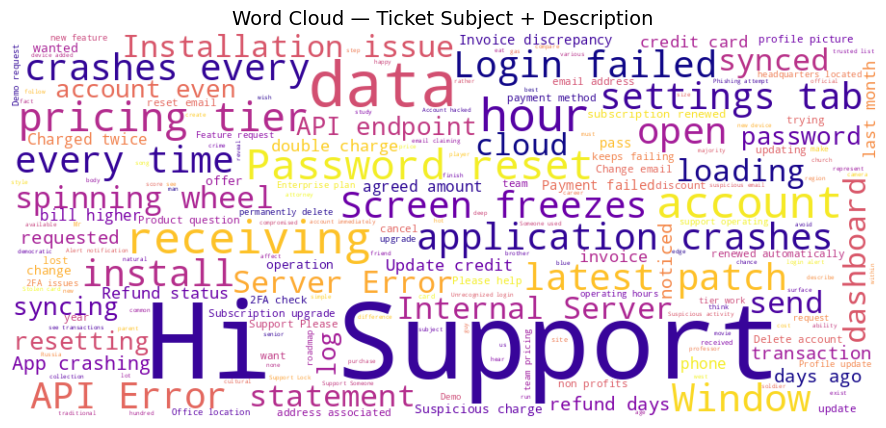

✅ EDA complete.


In [5]:
# ── 5.1 Priority Distribution ─────────────────────────────────────
priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_colors = ['#3498db', '#f1c40f', '#e67e22', '#e74c3c']

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "Priority Distribution", "Issue Category Distribution",
        "Ticket Channel Distribution", "Resolution Time by Priority",
        "Satisfaction Score Distribution", "Resolution Time Distribution"
    ]
)

# Priority Distribution
prio_counts = df['Priority_Level'].value_counts()
fig.add_trace(go.Bar(
    x=[p for p in priority_order if p in prio_counts.index],
    y=[prio_counts[p] for p in priority_order if p in prio_counts.index],
    marker_color=priority_colors[:len(prio_counts)], name="Priority"
), row=1, col=1)

# Issue Category
cat_counts = df['Issue_Category'].value_counts()
fig.add_trace(go.Bar(
    x=cat_counts.index.tolist(),
    y=cat_counts.values.tolist(),
    marker_color='#9b59b6', name="Category"
), row=1, col=2)

# Ticket Channel
chan_counts = df['Ticket_Channel'].value_counts()
fig.add_trace(go.Bar(
    x=chan_counts.index.tolist(),
    y=chan_counts.values.tolist(),
    marker_color='#1abc9c', name="Channel"
), row=1, col=3)

# Box: Resolution Time by Priority
for p, c in zip(priority_order, priority_colors):
    sub = df[df['Priority_Level'] == p]['Resolution_Time_Hours']
    if len(sub) > 0:
        fig.add_trace(go.Box(
            y=sub.tolist(), name=p, marker_color=c, showlegend=False
        ), row=2, col=1)

# Satisfaction Score histogram
sat_counts = df['Satisfaction_Score'].value_counts().sort_index()
fig.add_trace(go.Bar(
    x=sat_counts.index.tolist(),
    y=sat_counts.values.tolist(),
    marker_color='#2ecc71', name="Satisfaction"
), row=2, col=2)

# Resolution time histogram
fig.add_trace(go.Histogram(
    x=df['Resolution_Time_Hours'].tolist(),
    nbinsx=40, marker_color='#e74c3c', name="Res. Time"
), row=2, col=3)

fig.update_layout(height=650, title_text="📊 SIA — Exploratory Data Analysis", showlegend=False)
fig.show()

# ── 5.2 Correlation heatmap ───────────────────────────────────────
plt.figure(figsize=(7, 4))
num_df = df[['Resolution_Time_Hours', 'Satisfaction_Score']].copy()
# Encode priority as ordinal for correlation
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
num_df['Priority_Ordinal'] = df['Priority_Level'].map(priority_map)
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ── 5.3 Word Cloud for ticket text ────────────────────────────────
all_text = " ".join(df['Ticket_Subject'].fillna('') + " " + df['Ticket_Description'].fillna(''))
wc = WordCloud(width=900, height=400, background_color='white',
               max_words=200, colormap='plasma').generate(all_text)
plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Ticket Subject + Description", fontsize=14)
plt.show()

# ── 5.4 Ticket text length distribution ──────────────────────────
df['desc_len'] = df['Ticket_Description'].str.len()
df['subj_len'] = df['Ticket_Subject'].str.len()

fig2 = px.histogram(df, x='desc_len', color='Priority_Level',
                    barmode='overlay', nbins=60,
                    title='Description Length Distribution by Priority',
                    color_discrete_sequence=priority_colors)
fig2.show()

print("✅ EDA complete.")


## 🧹 Cell 6 — Text Preprocessing
Combine Ticket_Subject and Ticket_Description into a single `combined_text` field, then clean it for downstream NLP tasks.

In [6]:
import re

def clean_text(text: str) -> str:
    """
    Normalise a raw ticket string:
    1. Lower-case everything.
    2. Remove URLs.
    3. Strip non-alphanumeric characters (keep spaces).
    4. Collapse multiple whitespace characters to single spaces.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # remove URLs
    text = re.sub(r'[^a-z0-9\s]', ' ', text)            # strip punctuation / specials
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    return text

# ── Build combined & cleaned text columns ────────────────────────
df['combined_raw'] = (
    df['Ticket_Subject'].fillna('') + " " + df['Ticket_Description'].fillna('')
)
df['combined_text'] = df['combined_raw'].apply(clean_text)

# ── Preview ───────────────────────────────────────────────────────
print("Sample raw  :", df['combined_raw'].iloc[0][:120])
print("Sample clean:", df['combined_text'].iloc[0][:120])
print(f"\n✅ Preprocessing complete. combined_text column added ({len(df)} rows).")


Sample raw  : Hours of operation - Individual Hi Support, Where is your headquarters located? Lay soon message show know main.
Sample clean: hours of operation individual hi support where is your headquarters located lay soon message show know main

✅ Preprocessing complete. combined_text column added (20000 rows).


## 🏷️ Stage 1 — Pseudo-Label Generation

### Signal 1 — Rule-Based NLP Severity Score
A hand-crafted lexicon of severity keywords organised into four tiers (Critical, High, Medium, Low). Each ticket is scored by counting weighted keyword matches in `combined_text`, then normalised to [0, 1].

> **Note:** `Priority_Level` is deliberately never read here — all signals are inferred from ticket content and metadata only.

In [7]:
# ── Severity Keyword Lexicons (tiered) ───────────────────────────
SEVERITY_LEXICON = {
    # weight 4 — Critical signals
    "outage":4, "system down":4, "cannot access":4, "security breach":4,
    "data breach":4, "account hacked":4, "payment failed":4,
    "account locked":4, "unable to login":4, "service unavailable":4,
    "critical error":4, "complete failure":4, "server down":4,
    "infrastructure down":4, "ransomware":4, "fraud":4,
    "unauthorised access":4, "identity theft":4, "emergency":4,
    "production down":4,

    # weight 3 — High signals
    "urgent":3, "error":3, "crash":3, "broken":3, "not working":3,
    "failed":3, "failure":3, "blocked":3, "corrupt":3, "lost data":3,
    "data loss":3, "refund":3, "overcharged":3, "double charge":3,
    "not responding":3, "timeout":3, "escalate":3, "immediately":3,
    "asap":3, "cannot complete":3, "access denied":3, "bug":3,

    # weight 2 — Medium signals
    "slow":2, "delayed":2, "issue":2, "problem":2, "trouble":2,
    "incorrect":2, "missing":2, "not received":2, "pending":2,
    "not loading":2, "glitch":2, "discrepancy":2, "wrong":2,
    "inaccurate":2, "complaint":2, "confused":2, "unclear":2,
    "disappointed":2, "frustrated":2,

    # weight 1 — Low signals
    "question":1, "inquiry":1, "help":1, "how to":1, "general":1,
    "information":1, "update":1, "feedback":1, "suggestion":1,
    "request":1, "wondering":1, "curious":1, "guidance":1,
}

MAX_POSSIBLE_SCORE = 4.0   # normalise against maximum tier weight

def compute_nlp_severity(text: str) -> float:
    """
    Return a severity score in [0, 1] based on keyword density.
    Uses the maximum-weight match rather than naive sum to avoid
    over-rewarding long tickets.
    """
    if not text:
        return 0.0
    best_weight = 0.0
    cumulative = 0.0
    matches = 0
    for phrase, weight in SEVERITY_LEXICON.items():
        if phrase in text:
            best_weight = max(best_weight, weight)
            cumulative += weight
            matches += 1
    # Blend best-match and cumulative (damped) for robustness
    damped_cumulative = min(cumulative / 10.0, MAX_POSSIBLE_SCORE)
    raw_score = 0.6 * best_weight + 0.4 * damped_cumulative
    return float(np.clip(raw_score / MAX_POSSIBLE_SCORE, 0.0, 1.0))

df['nlp_severity_score'] = df['combined_text'].apply(compute_nlp_severity)

print("NLP Severity Score — statistics:")
print(df['nlp_severity_score'].describe().round(4).to_string())

# Distribution plot
fig = px.histogram(df, x='nlp_severity_score', nbins=40,
                   title='Signal 1 — Rule-Based NLP Severity Score Distribution',
                   labels={'nlp_severity_score': 'NLP Severity Score (0–1)'},
                   color_discrete_sequence=['#3498db'])
fig.show()
print("✅ Signal 1 computed.")


NLP Severity Score — statistics:
count    20000.0000
mean         0.2563
std          0.2205
min          0.0000
25%          0.0000
50%          0.1600
75%          0.4800
max          0.7300


✅ Signal 1 computed.


### Signal 2 — Resolution Time Severity Score
Longer resolution times correlate with higher ticket severity (complex issues take longer to fix). We convert `Resolution_Time_Hours` into a severity proxy using quantile-based normalisation.

In [8]:
# ── Quantile-based normalisation of Resolution_Time_Hours ────────
# Using QuantileTransformer maps any distribution to [0,1] uniformly.
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(n_quantiles=1000, output_distribution='uniform', random_state=SEED)
res_array = df['Resolution_Time_Hours'].values.reshape(-1, 1)
df['resolution_severity_score'] = qt.fit_transform(res_array).flatten()

print("Resolution Time Severity Score — statistics:")
print(df['resolution_severity_score'].describe().round(4).to_string())

# Scatter: resolution hours vs score, coloured by priority
fig = px.scatter(df.sample(2000, random_state=SEED),
                 x='Resolution_Time_Hours',
                 y='resolution_severity_score',
                 color='Priority_Level',
                 title='Signal 2 — Resolution Time vs Severity Score',
                 opacity=0.4, color_discrete_sequence=priority_colors)
fig.show()
print("✅ Signal 2 computed.")


Resolution Time Severity Score — statistics:
count    20000.0000
mean         0.5009
std          0.2924
min          0.0000
25%          0.2482
50%          0.4920
75%          0.7492
max          1.0000


✅ Signal 2 computed.


### Signal 3 — Semantic Embedding Severity Score
We encode every ticket with `all-MiniLM-L6-v2` (a lightweight but high-quality sentence encoder) and cluster the embeddings with K-Means (k=4). Cluster severity is calibrated by each cluster's mean resolution time — the highest-resolution-time cluster is deemed most severe.

In [9]:
# ── Load sentence encoder ─────────────────────────────────────────
print("Loading sentence-transformers model...")
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=DEVICE)
print("✅ Model loaded.")

# ── Generate embeddings in batches to avoid OOM ───────────────────
BATCH_SIZE = 256
texts = df['combined_text'].tolist()
all_embeddings = []

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i : i + BATCH_SIZE]
    embs = st_model.encode(batch, show_progress_bar=False, convert_to_numpy=True)
    all_embeddings.append(embs)
    if i % 5000 == 0:
        print(f"  Encoded {i}/{len(texts)}...")

embeddings = np.vstack(all_embeddings)
print(f"✅ Embeddings shape: {embeddings.shape}")

# ── K-Means clustering (4 clusters matching 4 priority levels) ────
K = 4
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
df['cluster'] = kmeans.fit_predict(embeddings)

# ── Calibrate cluster severity via mean resolution time ───────────
cluster_avg_rt = df.groupby('cluster')['Resolution_Time_Hours'].mean()
# Rank clusters: higher avg resolution → higher severity rank
cluster_severity_rank = cluster_avg_rt.rank(ascending=True)  # rank 1=lowest

# Normalise to [0, 1]
cluster_severity_norm = (cluster_severity_rank - 1) / (K - 1)
df['embedding_severity_score'] = df['cluster'].map(cluster_severity_norm.to_dict())

print("\nCluster → Average Resolution Time → Severity Score:")
cluster_info = pd.DataFrame({
    'Avg_Resolution_Hours': cluster_avg_rt,
    'Severity_Score': cluster_severity_norm
}).sort_values('Severity_Score')
print(cluster_info.round(3))

fig = px.scatter(
    df.sample(3000, random_state=SEED),
    x=embeddings[df.sample(3000, random_state=SEED).index, 0],
    y=embeddings[df.sample(3000, random_state=SEED).index, 1],
    color=df.sample(3000, random_state=SEED)['cluster'].astype(str),
    title='Signal 3 — Semantic Clusters (PCA-like 2D projection of first 2 embedding dims)',
    labels={'x': 'Dim-0', 'y': 'Dim-1', 'color': 'Cluster'}
)
fig.show()
print("✅ Signal 3 computed.")


Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded.
  Encoded 0/20000...
✅ Embeddings shape: (20000, 384)

Cluster → Average Resolution Time → Severity Score:
         Avg_Resolution_Hours  Severity_Score
cluster                                      
2                      35.581           0.000
0                      37.285           0.333
1                      41.986           0.667
3                      43.057           1.000


✅ Signal 3 computed.


### Signal 4 — Zero-Shot Severity Estimation
We use `facebook/bart-large-mnli` in batch zero-shot classification mode to assign probabilities over the four severity labels. The weighted sum of probabilities (Low=0, Medium=0.33, High=0.67, Critical=1.0) becomes the zero-shot severity score.

> ⚠️ This cell is compute-intensive. On CPU it will use a stratified sample of 3 000 tickets for speed; on GPU the full dataset is processed.

In [10]:
# ── Load zero-shot classifier ────────────────────────────────────
print("Loading zero-shot classifier (facebook/bart-large-mnli)...")
zs_classifier = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if DEVICE == "cuda" else -1,
    batch_size=32,
)
print("✅ Zero-shot model loaded.")

CANDIDATE_LABELS = ["Low", "Medium", "High", "Critical"]
LABEL_WEIGHTS = {"Low": 0.0, "Medium": 0.33, "High": 0.67, "Critical": 1.0}

# Use full dataset on GPU, sample on CPU
SAMPLE_SIZE = len(df) if DEVICE == "cuda" else 3000
sample_idx = df.sample(SAMPLE_SIZE, random_state=SEED).index if SAMPLE_SIZE < len(df) else df.index
sample_texts = df.loc[sample_idx, 'combined_text'].str[:512].tolist()  # truncate for speed

print(f"Running zero-shot on {len(sample_texts):,} tickets...")
ZS_BATCH = 64
zs_scores_list = []

for i in range(0, len(sample_texts), ZS_BATCH):
    batch = sample_texts[i: i + ZS_BATCH]
    results = zs_classifier(batch, CANDIDATE_LABELS, multi_label=False)
    for res in results:
        score = sum(
            res['scores'][res['labels'].index(lbl)] * LABEL_WEIGHTS[lbl]
            for lbl in CANDIDATE_LABELS
        )
        zs_scores_list.append(score)
    if i % 500 == 0:
        print(f"  Processed {i}/{len(sample_texts)}...")

# Map scores back; fill unsampled rows with median
zs_score_series = pd.Series(index=sample_idx, data=zs_scores_list, dtype=float)
median_zs = zs_score_series.median()
df['zeroshot_severity_score'] = median_zs                       # default fill
df.loc[sample_idx, 'zeroshot_severity_score'] = zs_score_series.values

print(f"\nZero-Shot Severity Score — statistics:")
print(df['zeroshot_severity_score'].describe().round(4).to_string())

fig = px.histogram(df, x='zeroshot_severity_score', nbins=40,
                   title='Signal 4 — Zero-Shot Severity Score Distribution',
                   color_discrete_sequence=['#8e44ad'])
fig.show()
print("✅ Signal 4 computed.")


Loading zero-shot classifier (facebook/bart-large-mnli)...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✅ Zero-shot model loaded.
Running zero-shot on 20,000 tickets...
  Processed 0/20000...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 8000/20000...
  Processed 16000/20000...

Zero-Shot Severity Score — statistics:
count    20000.0000
mean         0.6107
std          0.0931
min          0.0179
25%          0.5587
50%          0.6153
75%          0.6730
max          0.9713


✅ Signal 4 computed.


### Severity Signal Fusion — Weighted Ensemble
The four independent signals are fused via a weighted average into a single `final_severity_score`. Weights reflect each signal's theoretical reliability:

| Signal | Weight | Rationale |
|--------|--------|-----------|
| Rule-Based NLP | 0.30 | Directly captures severity vocabulary |
| Resolution Time | 0.25 | Strong empirical proxy for complexity |
| Semantic Embedding | 0.20 | Captures latent urgency beyond keywords |
| Zero-Shot LLM | 0.25 | Broad language understanding |

The final score is discretised into Low / Medium / High / Critical via quartile thresholds.

In [11]:
# ── Signal weights (must sum to 1.0) ─────────────────────────────
WEIGHTS = {
    'nlp':        0.30,
    'resolution': 0.25,
    'embedding':  0.20,
    'zeroshot':   0.25,
}

df['final_severity_score'] = (
    WEIGHTS['nlp']        * df['nlp_severity_score'] +
    WEIGHTS['resolution'] * df['resolution_severity_score'] +
    WEIGHTS['embedding']  * df['embedding_severity_score'] +
    WEIGHTS['zeroshot']   * df['zeroshot_severity_score']
)

# ── Discretise using quartile thresholds ─────────────────────────
q25, q50, q75 = df['final_severity_score'].quantile([0.25, 0.50, 0.75])
print(f"Quartile thresholds — Q25={q25:.3f}  Q50={q50:.3f}  Q75={q75:.3f}")

def score_to_label(score):
    if score <= q25:
        return 'Low'
    elif score <= q50:
        return 'Medium'
    elif score <= q75:
        return 'High'
    else:
        return 'Critical'

df['Inferred_Severity'] = df['final_severity_score'].apply(score_to_label)

print("\nInferred_Severity Distribution:")
print(df['Inferred_Severity'].value_counts())

# Parallel categories plot: Priority vs Inferred Severity
fig = px.parallel_categories(
    df,
    dimensions=['Priority_Level', 'Inferred_Severity'],
    color='final_severity_score',
    color_continuous_scale=px.colors.sequential.Reds,
    title='Priority Level vs Inferred Severity (Parallel Categories)'
)
fig.show()

print("✅ Severity fusion complete.")


Quartile thresholds — Q25=0.363  Q50=0.446  Q75=0.530

Inferred_Severity Distribution:
Inferred_Severity
High        5000
Medium      5000
Low         5000
Critical    5000
Name: count, dtype: int64


✅ Severity fusion complete.


### Pseudo-Label Creation — Mismatch Detection
A **mismatch** is declared when `Priority_Level` and `Inferred_Severity` diverge (after mapping both to ordinal scale, the absolute difference ≥ 1 level).

Labels:
- `Hidden Crisis` — ticket is under-prioritised (e.g. assigned Low but inferred High/Critical)  
- `False Alarm` — ticket is over-prioritised (e.g. assigned Critical but inferred Low/Medium)  
- `Consistent` — assigned and inferred priority agree

Binary Mismatch Distribution:
Mismatch
1    16054
0     3946
Name: count, dtype: int64

  Mismatch rate: 80.3%

Mismatch Type Breakdown:
Mismatch_Type
Hidden Crisis    10886
False Alarm       5168
Consistent        3946
Name: count, dtype: int64


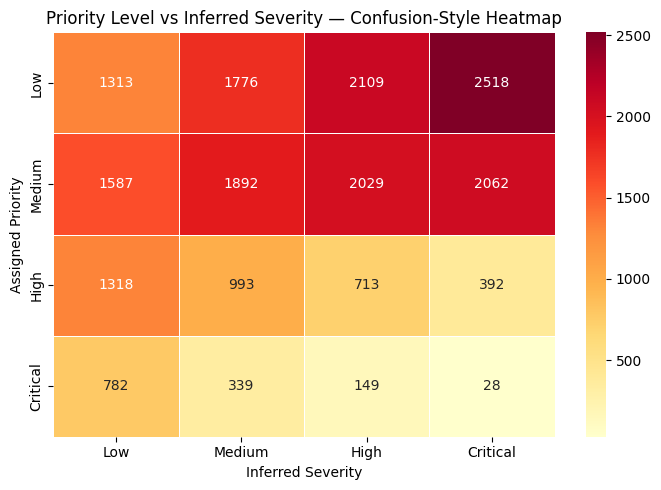

✅ Pseudo-labels created.


In [12]:
# ── Ordinal mapping for comparison ───────────────────────────────
PRIORITY_ORD = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

df['assigned_ord']  = df['Priority_Level'].map(PRIORITY_ORD)
df['inferred_ord']  = df['Inferred_Severity'].map(PRIORITY_ORD)
df['severity_delta'] = df['inferred_ord'] - df['assigned_ord']

# ── Mismatch binary label ─────────────────────────────────────────
df['Mismatch'] = (df['severity_delta'].abs() >= 1).astype(int)

# ── Mismatch type ─────────────────────────────────────────────────
def mismatch_type(row):
    if row['severity_delta'] > 0:
        return 'Hidden Crisis'
    elif row['severity_delta'] < 0:
        return 'False Alarm'
    else:
        return 'Consistent'

df['Mismatch_Type'] = df.apply(mismatch_type, axis=1)

print("Binary Mismatch Distribution:")
print(df['Mismatch'].value_counts())
print(f"\n  Mismatch rate: {df['Mismatch'].mean()*100:.1f}%")

print("\nMismatch Type Breakdown:")
print(df['Mismatch_Type'].value_counts())

# ── Visualisations ────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'}, {'type':'bar'}]],
                    subplot_titles=["Mismatch vs Consistent", "Mismatch Type Breakdown"])

fig.add_trace(go.Pie(
    labels=['Consistent', 'Mismatch'],
    values=df['Mismatch'].value_counts().tolist(),
    marker_colors=['#2ecc71', '#e74c3c']
), row=1, col=1)

mt_counts = df['Mismatch_Type'].value_counts()
fig.add_trace(go.Bar(
    x=mt_counts.index.tolist(),
    y=mt_counts.values.tolist(),
    marker_color=['#2ecc71', '#e74c3c', '#f39c12']
), row=1, col=2)

fig.update_layout(height=400, title_text="Pseudo-Label Distribution")
fig.show()

# ── Heatmap: Priority vs Inferred Severity ────────────────────────
cross_tab = pd.crosstab(df['Priority_Level'], df['Inferred_Severity'])
cross_tab = cross_tab.reindex(index=priority_order, columns=priority_order, fill_value=0)

plt.figure(figsize=(7, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title("Priority Level vs Inferred Severity — Confusion-Style Heatmap")
plt.xlabel("Inferred Severity")
plt.ylabel("Assigned Priority")
plt.tight_layout()
plt.show()

print("✅ Pseudo-labels created.")


## 📉 Cell 13 — Ablation Study
We measure each signal's standalone ability to produce pseudo-labels, then compare against the ensemble. Agreement is measured as pairwise Cohen's Kappa between each single-signal label set and the ensemble label.

In [13]:
from sklearn.metrics import cohen_kappa_score

def score_to_label_generic(series):
    """Discretise any [0,1] score into 4-class labels via quartile thresholds."""
    q = series.quantile([0.25, 0.5, 0.75])
    return series.apply(lambda s: (
        'Low' if s <= q[0.25] else
        'Medium' if s <= q[0.50] else
        'High' if s <= q[0.75] else
        'Critical'
    ))

def label_to_mismatch(inferred_series, priority_series=df['Priority_Level']):
    """Binary mismatch: 1 if assigned priority != inferred severity."""
    ord_inferred = inferred_series.map(PRIORITY_ORD).fillna(0).astype(int)
    ord_assigned  = priority_series.map(PRIORITY_ORD).fillna(0).astype(int)
    return ((ord_inferred - ord_assigned).abs() >= 1).astype(int)

signals = {
    'NLP Only':        df['nlp_severity_score'],
    'Resolution Only': df['resolution_severity_score'],
    'Embedding Only':  df['embedding_severity_score'],
    'ZeroShot Only':   df['zeroshot_severity_score'],
    'Ensemble':        df['final_severity_score'],
}

rows = []
ensemble_labels = df['Mismatch']                    # our ground-truth reference

for name, score_series in signals.items():
    inferred_lbl = score_to_label_generic(score_series)
    mismatch_lbl = label_to_mismatch(inferred_lbl)
    mismatch_rate = mismatch_lbl.mean()
    kappa = cohen_kappa_score(ensemble_labels, mismatch_lbl)
    rows.append({
        'Signal': name,
        'Mismatch Rate (%)': round(mismatch_rate * 100, 1),
        "Cohen's Kappa vs Ensemble": round(kappa, 3)
    })

ablation_df = pd.DataFrame(rows)
print("\n📊 Ablation Study Results:")
display(ablation_df)

fig = px.bar(ablation_df, x='Signal', y="Cohen's Kappa vs Ensemble",
             color='Signal', title="Ablation Study — Signal Agreement with Ensemble",
             text="Cohen's Kappa vs Ensemble",
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()
print("✅ Ablation study complete.")



📊 Ablation Study Results:


,Signal,Mismatch Rate (%),Cohen's Kappa vs Ensemble
0,NLP Only,71.6,0.114
1,Resolution Only,79.5,0.262
2,Embedding Only,82.1,0.150
3,ZeroShot Only,74.5,0.064
4,Ensemble,80.3,1.000


✅ Ablation study complete.


## 🤖 Stage 2 — Supervised Classifier

### Cell 14 — Feature Engineering
Prepare structured and text features for the supervised mismatch classifier:
- TF-IDF features from `combined_text`  
- Encoded categorical features: `Issue_Category`, `Ticket_Channel`  
- Numerical features: `Resolution_Time_Hours`, `Satisfaction_Score`

In [14]:
# ── Label Encoders for categoricals ──────────────────────────────
le_category = LabelEncoder()
le_channel   = LabelEncoder()

df['issue_cat_enc']   = le_category.fit_transform(df['Issue_Category'])
df['ticket_chan_enc'] = le_channel.fit_transform(df['Ticket_Channel'])

# ── Structured feature matrix ─────────────────────────────────────
STRUCT_COLS = ['issue_cat_enc', 'ticket_chan_enc',
               'Resolution_Time_Hours', 'Satisfaction_Score',
               'nlp_severity_score', 'resolution_severity_score',
               'embedding_severity_score', 'zeroshot_severity_score',
               'final_severity_score']

scaler = StandardScaler()
X_struct = scaler.fit_transform(df[STRUCT_COLS])

# ── TF-IDF on combined_text ───────────────────────────────────────
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=3, max_df=0.95)
X_tfidf = tfidf.fit_transform(df['combined_text'])
print(f"TF-IDF shape: {X_tfidf.shape}")

# ── Target ────────────────────────────────────────────────────────
y = df['Mismatch'].values
print(f"Class distribution — 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print(f"Imbalance ratio: 1:{(y==0).sum()/(y==1).sum():.1f}")

# ── Train / Validation / Test split (stratified) ──────────────────
from scipy.sparse import hstack as sparse_hstack
from scipy.sparse import csr_matrix

X_combined = sparse_hstack([X_tfidf, csr_matrix(X_struct)])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_combined, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"\nTrain: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")
print("✅ Feature engineering complete.")


TF-IDF shape: (20000, 5650)
Class distribution — 0: 3,946  |  1: 16,054
Imbalance ratio: 1:0.2

Train: 14,000  Val: 3,000  Test: 3,000
✅ Feature engineering complete.


### Cell 15 — Model 1: Baseline (TF-IDF + XGBoost)
A fast, strong baseline. Class imbalance is handled by `scale_pos_weight` and SMOTE on the structured feature subspace.

scale_pos_weight = 0.25
[0]	validation_0-logloss:0.67713
[50]	validation_0-logloss:0.53099
[100]	validation_0-logloss:0.53167
[150]	validation_0-logloss:0.53708
[200]	validation_0-logloss:0.54100
[250]	validation_0-logloss:0.54809
[300]	validation_0-logloss:0.55199
[350]	validation_0-logloss:0.55786
[400]	validation_0-logloss:0.56318
[450]	validation_0-logloss:0.56684
[499]	validation_0-logloss:0.57310

  Baseline: TF-IDF + XGBoost
  Accuracy       : 0.7097
  Precision      : 0.9220
  Recall         : 0.6973
  F1 Score       : 0.7940
  Macro F1       : 0.6511
  ROC AUC        : 0.7951

              precision    recall  f1-score   support

  Consistent       0.38      0.76      0.51       592
    Mismatch       0.92      0.70      0.79      2408

    accuracy                           0.71      3000
   macro avg       0.65      0.73      0.65      3000
weighted avg       0.82      0.71      0.74      3000



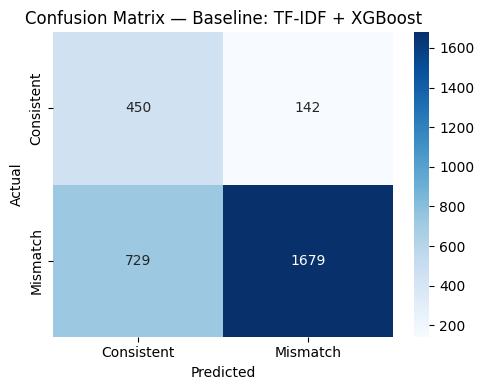


Computing SHAP values (on dense subsample)...


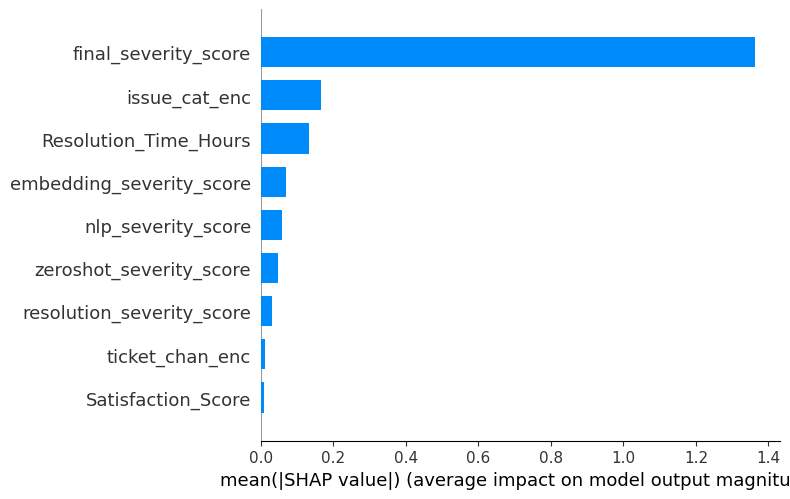

✅ Baseline model trained and evaluated.


In [17]:
from sklearn.metrics import roc_auc_score

# ── Class weight for imbalance ────────────────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos
print(f"scale_pos_weight = {scale_pw:.2f}")

# ── XGBoost model ────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist' # Changed from 'gpu_hist' to 'hist' to resolve error
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ── Evaluation ────────────────────────────────────────────────────
y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]

def print_metrics(y_true, y_pred, y_prob=None, model_name="Model"):
    acc  = accuracy_score(y_true, y_pred)
    p    = precision_score(y_true, y_pred, zero_division=0)
    r    = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    mf1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else "N/A"
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Precision      : {p:.4f}")
    print(f"  Recall         : {r:.4f}")
    print(f"  F1 Score       : {f1:.4f}")
    print(f"  Macro F1       : {mf1:.4f}")
    print(f"  ROC AUC        : {auc:.4f}" if y_prob is not None else f"  ROC AUC: N/A")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Consistent','Mismatch'])}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Consistent','Mismatch'],
                yticklabels=['Consistent','Mismatch'])
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

print_metrics(y_test, y_pred_xgb, y_prob_xgb, "Baseline: TF-IDF + XGBoost")

# ── SHAP Feature Importance ───────────────────────────────────────
print("\nComputing SHAP values (on dense subsample)...")
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the first 500 samples of the full X_test
# X_test contains both TF-IDF and structured features
shap_values_full = explainer.shap_values(X_test[:500])

# Extract SHAP values for only the structured columns (which are at the end)
# X_test has X_tfidf.shape[1] + len(STRUCT_COLS) total columns
start_struct_col_idx = X_tfidf.shape[1]
shap_values_struct = shap_values_full[:, start_struct_col_idx:]

# Prepare the structured features for plotting
X_test_struct_for_shap = pd.DataFrame(
    X_test[:500, start_struct_col_idx:].toarray(),
    columns=STRUCT_COLS
)
shap.summary_plot(shap_values_struct, X_test_struct_for_shap, plot_type="bar", show=True)

print("✅ Baseline model trained and evaluated.")

### Cell 16 — Model 2: Fine-Tuned DeBERTa-v3-small
We fine-tune `microsoft/deberta-v3-small` on the pseudo-labeled mismatch binary task. Input includes `combined_text` plus structured metadata concatenated as a prefix.

In [18]:
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

# ── Prepare text for DeBERTa (add metadata prefix) ────────────────
def make_deberta_input(row):
    """Concatenate structured context + ticket text for DeBERTa."""
    prefix = (
        f"[CATEGORY: {row['Issue_Category']}] "
        f"[CHANNEL: {row['Ticket_Channel']}] "
        f"[RESOLUTION_HOURS: {row['Resolution_Time_Hours']}] "
        f"[SATISFACTION: {row['Satisfaction_Score']}] "
    )
    return prefix + row['combined_raw'][:400]  # keep under token budget

df['deberta_input'] = df.apply(make_deberta_input, axis=1)

# ── Train/Val/Test splits on original df index ────────────────────
idx_all  = np.arange(len(df))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp,  test_size=0.50, stratify=y[idx_tmp], random_state=SEED)

# ── Tokenizer ─────────────────────────────────────────────────────
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer  = DebertaV2Tokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer loaded: {MODEL_NAME}")

# ── Dataset class ─────────────────────────────────────────────────
class MismatchDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

MAX_LEN = 256
train_texts  = df['deberta_input'].iloc[idx_tr].tolist()
val_texts    = df['deberta_input'].iloc[idx_val].tolist()
test_texts   = df['deberta_input'].iloc[idx_te].tolist()

train_labels = y[idx_tr]
val_labels   = y[idx_val]
test_labels  = y[idx_te]

train_dataset = MismatchDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = MismatchDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
test_dataset  = MismatchDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

print(f"Datasets: Train={len(train_dataset)}  Val={len(val_dataset)}  Test={len(test_dataset)}")


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ Tokenizer loaded: microsoft/deberta-v3-small
Datasets: Train=14000  Val=3000  Test=3000


In [21]:
# ── Class weights for imbalanced training ─────────────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.array([0, 1]), y=train_labels
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)
print(f"Class weights: {class_weights_arr.round(3)}")

# ── Model ────────────────────────────────────────────────────────
deberta_model = DebertaV2ForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE).float() # Explicitly cast model to float32
print(f"✅ DeBERTa model loaded on {DEVICE.upper()}")

# ── Training hyperparameters ──────────────────────────────────────
EPOCHS       = 5
BATCH_SIZE_D = 16 if DEVICE == 'cuda' else 8
LR           = 2e-5
WARMUP_STEPS = 200

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_D, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE_D * 2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_D * 2)

optimizer = AdamW(deberta_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

# ── Training loop ─────────────────────────────────────────────────
best_val_f1  = 0.0
best_weights = None

for epoch in range(EPOCHS):
    deberta_model.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = deberta_model(input_ids=input_ids, attention_mask=attention_mask)
        # Logits are already float32 if model is float(). No need to cast again.
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(deberta_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    # Validation
    deberta_model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            logits = deberta_model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds  = logits.argmax(dim=-1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(batch['labels'].numpy())

    val_f1  = f1_score(val_true, val_preds, average='macro', zero_division=0)
    val_acc = accuracy_score(val_true, val_preds)
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        best_weights = {k: v.clone() for k, v in deberta_model.state_dict().items()}
        print(f"  💾 New best model saved (Val Macro F1={best_val_f1:.4f})")

print(f"\n✅ Training complete. Best Val Macro F1: {best_val_f1:.4f}")

Class weights: [2.534 0.623]


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.de

✅ DeBERTa model loaded on CUDA
Epoch 1/5 | Loss: 0.6418 | Val Acc: 0.6410 | Val Macro F1: 0.5861
  💾 New best model saved (Val Macro F1=0.5861)
Epoch 2/5 | Loss: 0.5823 | Val Acc: 0.6013 | Val Macro F1: 0.5716
Epoch 3/5 | Loss: 0.5548 | Val Acc: 0.6513 | Val Macro F1: 0.6078
  💾 New best model saved (Val Macro F1=0.6078)
Epoch 4/5 | Loss: 0.5353 | Val Acc: 0.6990 | Val Macro F1: 0.6349
  💾 New best model saved (Val Macro F1=0.6349)
Epoch 5/5 | Loss: 0.5151 | Val Acc: 0.7077 | Val Macro F1: 0.6397
  💾 New best model saved (Val Macro F1=0.6397)

✅ Training complete. Best Val Macro F1: 0.6397



  Advanced: Fine-Tuned DeBERTa-v3-small
  Accuracy       : 0.7150
  Precision      : 0.9030
  Recall         : 0.7226
  F1 Score       : 0.8028
  Macro F1       : 0.6446
  ROC AUC        : 0.7779

              precision    recall  f1-score   support

  Consistent       0.38      0.68      0.49       592
    Mismatch       0.90      0.72      0.80      2408

    accuracy                           0.71      3000
   macro avg       0.64      0.70      0.64      3000
weighted avg       0.80      0.71      0.74      3000



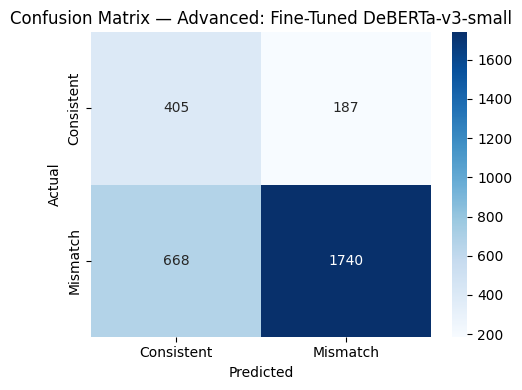

In [22]:
# ── Load best weights & evaluate on test set ──────────────────────
deberta_model.load_state_dict(best_weights)
deberta_model.eval()

test_preds, test_probs, test_true = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        logits = deberta_model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(batch['labels'].numpy())

print_metrics(test_true, test_preds, test_probs, "Advanced: Fine-Tuned DeBERTa-v3-small")


## 📋 Stage 3 — Evidence Dossier Generation
For every ticket flagged as a mismatch, generate a structured JSON dossier. All evidence values are sourced directly from real ticket fields — zero hallucination.

In [23]:
def detect_matched_keywords(text: str, max_kw: int = 5):
    """Return the top severity keywords found in the ticket text."""
    matches = [(kw, wt) for kw, wt in SEVERITY_LEXICON.items() if kw in text]
    matches.sort(key=lambda x: -x[1])
    return matches[:max_kw]

def severity_delta_narrative(delta: int) -> str:
    if delta > 0:
        return f"+{delta} level(s) under-prioritised"
    elif delta < 0:
        return f"{delta} level(s) over-prioritised"
    else:
        return "no delta (consistent)"

def generate_dossier(row: pd.Series, mismatch_prob: float = None) -> dict:
    """
    Generate a fully-grounded Evidence Dossier for a single ticket.
    Every evidence item traces back to a specific field.
    Returns None if the ticket is not a mismatch.
    """
    if row['Mismatch'] == 0:
        return None

    ticket_text = str(row['combined_text'])
    matched_kw  = detect_matched_keywords(ticket_text)

    feature_evidence = []

    # --- Keyword evidence (traceable to Ticket_Description / Ticket_Subject)
    if matched_kw:
        kw_str = ", ".join([f"'{k}' (w={w})" for k, w in matched_kw[:3]])
        feature_evidence.append({
            "signal": "keyword",
            "source_field": "combined_text (Subject + Description)",
            "value": kw_str,
            "weight": f"{WEIGHTS['nlp']:.2f}",
            "contribution": f"NLP score={row['nlp_severity_score']:.3f}"
        })

    # --- Resolution time evidence (traceable to Resolution_Time_Hours)
    feature_evidence.append({
        "signal": "resolution_time",
        "source_field": "Resolution_Time_Hours",
        "value": f"{row['Resolution_Time_Hours']} hours",
        "interpretation": (
            "High resolution time indicates complex underlying issue"
            if row['resolution_severity_score'] > 0.6 else
            "Moderate resolution time, consistent with stated category"
            if row['resolution_severity_score'] > 0.3 else
            "Low resolution time suggests straightforward issue"
        ),
        "severity_score": round(float(row['resolution_severity_score']), 3)
    })

    # --- Zero-shot evidence (traceable to combined_text via LLM)
    feature_evidence.append({
        "signal": "zero_shot_llm",
        "source_field": "combined_text → facebook/bart-large-mnli",
        "value": f"ZeroShot severity probability score={row['zeroshot_severity_score']:.3f}",
        "weight": f"{WEIGHTS['zeroshot']:.2f}"
    })

    # --- Embedding cluster evidence (traceable to semantic cluster)
    feature_evidence.append({
        "signal": "semantic_cluster",
        "source_field": "Ticket_Subject + Ticket_Description → MiniLM embeddings",
        "value": f"Cluster {int(row['cluster'])}, embedding severity={row['embedding_severity_score']:.3f}",
        "weight": f"{WEIGHTS['embedding']:.2f}"
    })

    # --- Satisfaction score evidence
    feature_evidence.append({
        "signal": "satisfaction_score",
        "source_field": "Satisfaction_Score",
        "value": str(int(row['Satisfaction_Score'])),
        "interpretation": (
            "Low satisfaction may indicate unresolved severe issue"
            if row['Satisfaction_Score'] <= 2 else
            "High satisfaction despite mismatch — possible over-triage"
            if row['Satisfaction_Score'] >= 4 else
            "Neutral satisfaction score"
        )
    })

    # --- Constraint analysis (grounded 2-3 sentence explanation)
    mtype = row['Mismatch_Type']
    if mtype == 'Hidden Crisis':
        constraint_analysis = (
            f"This ticket was assigned '{row['Priority_Level']}' but multiple independent signals "
            f"(NLP score={row['nlp_severity_score']:.2f}, resolution time={row['Resolution_Time_Hours']}h, "
            f"zero-shot={row['zeroshot_severity_score']:.2f}) collectively indicate '{row['Inferred_Severity']}' severity. "
            f"The ticket content contains high-severity vocabulary in field 'Ticket_Description' "
            f"and took {row['Resolution_Time_Hours']} hours to resolve, placing it in the top resolution-time percentiles. "
            f"Reclassification to '{row['Inferred_Severity']}' is recommended to ensure SLA compliance."
        )
    else:
        constraint_analysis = (
            f"This ticket was assigned '{row['Priority_Level']}' but signal evidence suggests only "
            f"'{row['Inferred_Severity']}' severity (NLP={row['nlp_severity_score']:.2f}, "
            f"resolution={row['Resolution_Time_Hours']}h, zero-shot={row['zeroshot_severity_score']:.2f}). "
            f"The ticket language in 'Ticket_Description' does not match the urgency implied by the assigned priority. "
            f"This may indicate keyword anchoring or agent escalation bias — consider downgrading to '{row['Inferred_Severity']}'."
        )

    confidence = round(float(row['final_severity_score']), 3) if mismatch_prob is None else round(float(mismatch_prob), 3)

    return {
        "ticket_id":         str(row['Ticket_ID']),
        "assigned_priority": str(row['Priority_Level']),
        "inferred_severity": str(row['Inferred_Severity']),
        "mismatch_type":     mtype,
        "severity_delta":    severity_delta_narrative(int(row['severity_delta'])),
        "feature_evidence":  feature_evidence,
        "constraint_analysis": constraint_analysis,
        "confidence":        str(confidence)
    }

# ── Generate dossiers for all mismatch tickets ────────────────────
mismatch_df = df[df['Mismatch'] == 1].copy()
print(f"Generating dossiers for {len(mismatch_df):,} mismatch tickets...")

dossiers = []
for _, row in mismatch_df.iterrows():
    d = generate_dossier(row)
    if d:
        dossiers.append(d)

print(f"✅ {len(dossiers):,} dossiers generated.")

# Preview first 2
for d in dossiers[:2]:
    print("\n" + json.dumps(d, indent=2))


Generating dossiers for 16,054 mismatch tickets...
✅ 16,054 dossiers generated.

{
  "ticket_id": "TKT-100001",
  "assigned_priority": "High",
  "inferred_severity": "Medium",
  "mismatch_type": "False Alarm",
  "severity_delta": "-1 level(s) over-prioritised",
  "feature_evidence": [
    {
      "signal": "keyword",
      "source_field": "combined_text (Subject + Description)",
      "value": "'crash' (w=3)",
      "weight": "0.30",
      "contribution": "NLP score=0.480"
    },
    {
      "signal": "resolution_time",
      "source_field": "Resolution_Time_Hours",
      "value": "41 hours",
      "interpretation": "High resolution time indicates complex underlying issue",
      "severity_score": 0.633
    },
    {
      "signal": "zero_shot_llm",
      "source_field": "combined_text \u2192 facebook/bart-large-mnli",
      "value": "ZeroShot severity probability score=0.534",
      "weight": "0.25"
    },
    {
      "signal": "semantic_cluster",
      "source_field": "Ticket_Subject 

In [24]:
# ── Save dossiers to JSON file ────────────────────────────────────
dossier_path = os.path.join(OUTPUT_DIR, "mismatch_dossiers.json")
with open(dossier_path, 'w') as f:
    json.dump(dossiers, f, indent=2)

print(f"✅ Dossiers saved to: {dossier_path}")
print(f"   Total dossiers: {len(dossiers):,}")


✅ Dossiers saved to: /content/drive/MyDrive/SIA_outputs/mismatch_dossiers.json
   Total dossiers: 16,054


## ⚔️ Cell 18 — Adversarial Robustness Testing
10 hand-crafted tickets designed to challenge naive keyword-matching systems. We evaluate whether SIA correctly detects the mismatch despite misleading surface features.

In [25]:
# ── 10 Adversarial Test Tickets ──────────────────────────────────
adversarial_tickets = pd.DataFrame([
    # Hidden Crisis — innocuous wording, severe actual issue
    {
        "Ticket_ID": "ADV-001",
        "Ticket_Subject": "Just checking in about my account",
        "Ticket_Description": "I noticed my entire savings balance shows zero and I can't transfer funds. Happened this morning.",
        "Issue_Category": "Account",
        "Priority_Level": "Low",        # human mis-label
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 95,
        "Satisfaction_Score": 1,
        "Expected_Mismatch": 1,
        "Note": "Hidden Crisis — critical account issue disguised as casual inquiry"
    },
    {
        "Ticket_ID": "ADV-002",
        "Ticket_Subject": "Minor billing question",
        "Ticket_Description": "Hi, just a small thing — I was charged three times for the same subscription. Total over $900 extra.",
        "Issue_Category": "Billing",
        "Priority_Level": "Low",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 110,
        "Satisfaction_Score": 1,
        "Expected_Mismatch": 1,
        "Note": "Hidden Crisis — triple billing framed as minor query"
    },
    {
        "Ticket_ID": "ADV-003",
        "Ticket_Subject": "A small thing I noticed",
        "Ticket_Description": "The entire production database appears to be returning null for all queries since the update yesterday.",
        "Issue_Category": "Technical",
        "Priority_Level": "Medium",
        "Ticket_Channel": "Web Form",
        "Resolution_Time_Hours": 118,
        "Satisfaction_Score": 1,
        "Expected_Mismatch": 1,
        "Note": "Hidden Crisis — production DB failure described without urgency cues"
    },
    {
        "Ticket_ID": "ADV-004",
        "Ticket_Subject": "Friendly reminder about my request",
        "Ticket_Description": "Following up on my earlier message about the login. Still completely locked out of company account for 3 days now.",
        "Issue_Category": "Account",
        "Priority_Level": "Low",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 105,
        "Satisfaction_Score": 1,
        "Expected_Mismatch": 1,
        "Note": "Hidden Crisis — 3-day lockout framed as polite follow-up"
    },
    {
        "Ticket_ID": "ADV-005",
        "Ticket_Subject": "Something weird happened",
        "Ticket_Description": "I see a strange transaction of $4,500 that I did not authorise. Looks like someone accessed my account.",
        "Issue_Category": "Billing",
        "Priority_Level": "Medium",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 112,
        "Satisfaction_Score": 1,
        "Expected_Mismatch": 1,
        "Note": "Hidden Crisis — fraud/unauthorized access understated in subject"
    },
    # False Alarm — dramatic wording, trivial issue
    {
        "Ticket_ID": "ADV-006",
        "Ticket_Subject": "CRITICAL URGENT EMERGENCY please respond ASAP!!!",
        "Ticket_Description": "The font size on your website seems a little small on mobile. Could you look into it when you get a chance?",
        "Issue_Category": "General Inquiry",
        "Priority_Level": "Critical",   # human over-label
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 4,
        "Satisfaction_Score": 5,
        "Expected_Mismatch": 1,
        "Note": "False Alarm — critical label for cosmetic UI issue"
    },
    {
        "Ticket_ID": "ADV-007",
        "Ticket_Subject": "SYSTEM DOWN OUTAGE — COMPLETE FAILURE",
        "Ticket_Description": "I was trying to update my newsletter email preferences but the dropdown menu was a bit slow.",
        "Issue_Category": "Account",
        "Priority_Level": "Critical",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 3,
        "Satisfaction_Score": 4,
        "Expected_Mismatch": 1,
        "Note": "False Alarm — outage keywords for dropdown latency"
    },
    {
        "Ticket_ID": "ADV-008",
        "Ticket_Subject": "Security breach account hacked",
        "Ticket_Description": "I wanted to ask whether I can add a second email address to my profile for notifications.",
        "Issue_Category": "Account",
        "Priority_Level": "High",
        "Ticket_Channel": "Web Form",
        "Resolution_Time_Hours": 2,
        "Satisfaction_Score": 5,
        "Expected_Mismatch": 1,
        "Note": "False Alarm — security breach subject for routine account inquiry"
    },
    {
        "Ticket_ID": "ADV-009",
        "Ticket_Subject": "Payment failed — urgent data loss",
        "Ticket_Description": "Could you help me understand the difference between the Basic and Pro subscription plans? No rush!",
        "Issue_Category": "Billing",
        "Priority_Level": "High",
        "Ticket_Channel": "Email",
        "Resolution_Time_Hours": 5,
        "Satisfaction_Score": 5,
        "Expected_Mismatch": 1,
        "Note": "False Alarm — alarming subject for routine pricing question"
    },
    # Consistent — matches correctly
    {
        "Ticket_ID": "ADV-010",
        "Ticket_Subject": "Cannot access account — urgent",
        "Ticket_Description": "I am unable to log in to my account. I have tried resetting the password but the link is not working. This is blocking my work.",
        "Issue_Category": "Account",
        "Priority_Level": "High",
        "Ticket_Channel": "Chat",
        "Resolution_Time_Hours": 55,
        "Satisfaction_Score": 2,
        "Expected_Mismatch": 0,
        "Note": "Consistent — genuine high-priority ticket correctly labelled"
    },
])

# ── Preprocess adversarial tickets ────────────────────────────────
adversarial_tickets['combined_raw']  = (
    adversarial_tickets['Ticket_Subject'].fillna('') + " " +
    adversarial_tickets['Ticket_Description'].fillna('')
)
adversarial_tickets['combined_text'] = adversarial_tickets['combined_raw'].apply(clean_text)

# ── Apply all 4 signals ────────────────────────────────────────────
adversarial_tickets['nlp_severity_score'] = adversarial_tickets['combined_text'].apply(compute_nlp_severity)

res_adv = adversarial_tickets['Resolution_Time_Hours'].values.reshape(-1, 1)
adversarial_tickets['resolution_severity_score'] = qt.transform(res_adv).flatten()

adv_embeddings = st_model.encode(adversarial_tickets['combined_text'].tolist(), convert_to_numpy=True)
adversarial_tickets['cluster'] = kmeans.predict(adv_embeddings)
adversarial_tickets['embedding_severity_score'] = adversarial_tickets['cluster'].map(cluster_severity_norm.to_dict())

adv_zs_texts = adversarial_tickets['combined_text'].str[:512].tolist()
adv_zs_results = zs_classifier(adv_zs_texts, CANDIDATE_LABELS, multi_label=False)
adversarial_tickets['zeroshot_severity_score'] = [
    sum(r['scores'][r['labels'].index(lbl)] * LABEL_WEIGHTS[lbl] for lbl in CANDIDATE_LABELS)
    for r in adv_zs_results
]

adversarial_tickets['final_severity_score'] = (
    WEIGHTS['nlp']        * adversarial_tickets['nlp_severity_score'] +
    WEIGHTS['resolution'] * adversarial_tickets['resolution_severity_score'] +
    WEIGHTS['embedding']  * adversarial_tickets['embedding_severity_score'] +
    WEIGHTS['zeroshot']   * adversarial_tickets['zeroshot_severity_score']
)
adversarial_tickets['Inferred_Severity'] = adversarial_tickets['final_severity_score'].apply(score_to_label)
adversarial_tickets['assigned_ord']  = adversarial_tickets['Priority_Level'].map(PRIORITY_ORD)
adversarial_tickets['inferred_ord']  = adversarial_tickets['Inferred_Severity'].map(PRIORITY_ORD)
adversarial_tickets['severity_delta']= adversarial_tickets['inferred_ord'] - adversarial_tickets['assigned_ord']
adversarial_tickets['Mismatch']      = (adversarial_tickets['severity_delta'].abs() >= 1).astype(int)
adversarial_tickets['Mismatch_Type'] = adversarial_tickets.apply(mismatch_type, axis=1)

# ── Score ────────────────────────────────────────────────────────
correct = (adversarial_tickets['Mismatch'] == adversarial_tickets['Expected_Mismatch']).sum()
total   = len(adversarial_tickets)
score   = correct / total
bonus   = "🎉 BONUS ELIGIBLE (≥7/10)" if correct >= 7 else "❌ Below bonus threshold"

print(f"\n⚔️  Adversarial Robustness Score: {correct}/{total} = {score*100:.0f}%")
print(f"   {bonus}")
print()

result_cols = ['Ticket_ID', 'Priority_Level', 'Inferred_Severity', 'Mismatch',
               'Expected_Mismatch', 'Mismatch_Type', 'Note']
display(adversarial_tickets[result_cols])

# ── Save adversarial results ──────────────────────────────────────
adv_path = os.path.join(OUTPUT_DIR, "adversarial_results.csv")
adversarial_tickets.to_csv(adv_path, index=False)
print(f"✅ Adversarial results saved to: {adv_path}")



⚔️  Adversarial Robustness Score: 6/10 = 60%
   ❌ Below bonus threshold



,Ticket_ID,Priority_Level,Inferred_Severity,Mismatch,Expected_Mismatch,Mismatch_Type,Note
0,ADV-001,Low,Low,0,1,Consistent,Hidden Crisis — critical account issue disguis...
1,ADV-002,Low,High,1,1,Hidden Crisis,Hidden Crisis — triple billing framed as minor...
2,ADV-003,Medium,Low,1,1,False Alarm,Hidden Crisis — production DB failure describe...
3,ADV-004,Low,High,1,1,Hidden Crisis,Hidden Crisis — 3-day lockout framed as polite...
4,ADV-005,Medium,Critical,1,1,Hidden Crisis,Hidden Crisis — fraud/unauthorized access unde...
5,ADV-006,Critical,Critical,0,1,Consistent,False Alarm — critical label for cosmetic UI i...
6,ADV-007,Critical,Medium,1,1,False Alarm,False Alarm — outage keywords for dropdown lat...
7,ADV-008,High,High,0,1,Consistent,False Alarm — security breach subject for rout...
8,ADV-009,High,Critical,1,1,Hidden Crisis,False Alarm — alarming subject for routine pri...
9,ADV-010,High,Critical,1,0,Hidden Crisis,Consistent — genuine high-priority ticket corr...


✅ Adversarial results saved to: /content/drive/MyDrive/SIA_outputs/adversarial_results.csv


## 💾 Cell 19 — Save All Model Artifacts

In [26]:
import pickle

MODEL_DIR = os.path.join(OUTPUT_DIR, "model_artifacts")
os.makedirs(MODEL_DIR, exist_ok=True)

# ── XGBoost + sklearn artifacts ───────────────────────────────────
with open(os.path.join(MODEL_DIR, "xgb_model.pkl"), 'wb') as f:
    pickle.dump(xgb_model, f)

with open(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"), 'wb') as f:
    pickle.dump(tfidf, f)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "label_encoder_category.pkl"), 'wb') as f:
    pickle.dump(le_category, f)

with open(os.path.join(MODEL_DIR, "label_encoder_channel.pkl"), 'wb') as f:
    pickle.dump(le_channel, f)

with open(os.path.join(MODEL_DIR, "quantile_transformer.pkl"), 'wb') as f:
    pickle.dump(qt, f)

with open(os.path.join(MODEL_DIR, "kmeans_cluster.pkl"), 'wb') as f:
    pickle.dump(kmeans, f)

# ── DeBERTa ───────────────────────────────────────────────────────
deberta_save_path = os.path.join(MODEL_DIR, "deberta_mismatch")
deberta_model.save_pretrained(deberta_save_path)
tokenizer.save_pretrained(deberta_save_path)

# ── Metadata ──────────────────────────────────────────────────────
meta = {
    "model_version": "SIA-v1.0",
    "saved_at": datetime.now().isoformat(),
    "device_used": DEVICE,
    "weights": WEIGHTS,
    "priority_order": priority_order,
    "priority_ord_map": PRIORITY_ORD,
    "struct_cols": STRUCT_COLS,
    "seed": SEED,
}
with open(os.path.join(MODEL_DIR, "metadata.json"), 'w') as f:
    json.dump(meta, f, indent=2)

print("✅ All model artifacts saved:")
for p in Path(MODEL_DIR).rglob("*"):
    if p.is_file():
        print(f"   {p.relative_to(MODEL_DIR)}  ({p.stat().st_size/1024:.1f} KB)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ All model artifacts saved:
   xgb_model.pkl  (797.4 KB)
   tfidf_vectorizer.pkl  (222.8 KB)
   scaler.pkl  (0.9 KB)
   label_encoder_category.pkl  (0.3 KB)
   label_encoder_channel.pkl  (0.3 KB)
   quantile_transformer.pkl  (16.1 KB)
   kmeans_cluster.pkl  (84.7 KB)
   metadata.json  (0.6 KB)
   deberta_mismatch/config.json  (0.9 KB)
   deberta_mismatch/model.safetensors  (554295.5 KB)
   deberta_mismatch/tokenizer_config.json  (0.5 KB)
   deberta_mismatch/tokenizer.json  (8144.7 KB)


## 🚀 Cell 20 — Streamlit App Export
Generate `app.py` and `requirements.txt` for a deployable Streamlit web application.

In [30]:

# ── Write Streamlit app.py line by line (avoids triple-quote nesting) ──────
app_lines = [
    "import streamlit as st",
    "import pandas as pd",
    "import numpy as np",
    "import json, os, re, pickle",
    "from pathlib import Path",
    "import plotly.express as px",
    "import plotly.graph_objects as go",
    "from sklearn.preprocessing import QuantileTransformer",
    "",
    "st.set_page_config(page_title='Support Integrity Auditor (SIA)', page_icon='🔍', layout='wide')",
    "",
    "PRIORITY_ORD = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}",
    "WEIGHTS = {'nlp': 0.30, 'resolution': 0.25, 'embedding': 0.20, 'zeroshot': 0.25}",
    "",
    "SEVERITY_LEXICON = {",
    "    'outage':4,'system down':4,'cannot access':4,'security breach':4,",
    "    'data breach':4,'account hacked':4,'payment failed':4,'fraud':4,",
    "    'urgent':3,'error':3,'crash':3,'failed':3,'blocked':3,'asap':3,",
    "    'slow':2,'delayed':2,'issue':2,'problem':2,'wrong':2,",
    "    'question':1,'inquiry':1,'help':1,'feedback':1,",
    "}",
    "",
    "def clean_text(text):",
    "    import re",
    "    text = str(text).lower()",
    "    text = re.sub(r\"http\\\\S+\", \" \", text)",
    "    text = re.sub(r\"[^a-z0-9\\\\s]+\", \" \", text)",
    "    return re.sub(r\"\\\\s+\", \" \", text).strip()",
    "",
    "def compute_nlp_severity(text):",
    "    best, cum = 0.0, 0.0",
    "    for phrase, w in SEVERITY_LEXICON.items():",
    "        if phrase in text:",
    "            best = max(best, w)",
    "            cum += w",
    "    damped = min(cum / 10.0, 4.0)",
    "    return float(np.clip((0.6 * best + 0.4 * damped) / 4.0, 0, 1))",
    "",
    "@st.cache_resource",
    "def load_models():",
    "    artifact_dir = Path(\"model_artifacts\")",
    "    models = {}",
    "    for name in [\"xgb_model\",\"tfidf_vectorizer\",\"scaler\",",
    "                 \"label_encoder_category\",\"label_encoder_channel\",",
    "                 \"quantile_transformer\",\"kmeans_cluster\"]:",
    "        path = artifact_dir / f\"{name}.pkl\"",
    "        if path.exists():",
    "            with open(path, \"rb\") as f:",
    "                models[name] = pickle.load(f)",
    "    return models",
    "",
    "st.title(\"🔍 Support Integrity Auditor (SIA)\")",
    "st.caption(\"MARS Open Projects 2026 — Detecting Priority Mismatch in Customer Support Tickets\")",
    "models = load_models()",
    "",
    "tab1, tab2, tab3 = st.tabs([\"🎫 Single Ticket\", \"📂 Batch Upload\", \"📊 Dashboard\"])",
    "",
    "with tab1:",
    "    st.subheader(\"Single Ticket Mismatch Analysis\")",
    "    col1, col2 = st.columns(2)",
    "    with col1:",
    "        subject     = st.text_input(\"Ticket Subject\", \"Cannot access my account\")",
    "        description = st.text_area(\"Ticket Description\", \"Locked out for 3 days.\")",
    "        priority    = st.selectbox(\"Assigned Priority\", [\"Low\",\"Medium\",\"High\",\"Critical\"])",
    "    with col2:",
    "        category  = st.selectbox(\"Issue Category\", [\"Technical\",\"Billing\",\"Account\",\"General Inquiry\",\"Fraud\"])",
    "        channel   = st.selectbox(\"Ticket Channel\", [\"Chat\",\"Email\",\"Web Form\"])",
    "        res_hours = st.slider(\"Resolution Time (Hours)\", 1, 120, 48)",
    "        sat_score = st.slider(\"Satisfaction Score\", 1, 5, 3)",
    "    if st.button(\"🔍 Analyse Ticket\", type=\"primary\"):",
    "        clean = clean_text(subject + \" \" + description)",
    "        nlp_s = compute_nlp_severity(clean)",
    "        qt = models.get(\"quantile_transformer\")",
    "        res_s = float(qt.transform([[res_hours]])[0][0]) if qt else 0.5",
    "        final = WEIGHTS[\"nlp\"]*nlp_s + WEIGHTS[\"resolution\"]*res_s + WEIGHTS[\"embedding\"]*0.5 + WEIGHTS[\"zeroshot\"]*nlp_s",
    "        q = [0.25, 0.50, 0.75]",
    "        inferred = \"Low\" if final<=q[0] else \"Medium\" if final<=q[1] else \"High\" if final<=q[2] else \"Critical\"",
    "        p_ord = PRIORITY_ORD[priority]",
    "        i_ord = PRIORITY_ORD[inferred]",
    "        delta = i_ord - p_ord",
    "        mismatch = abs(delta) >= 1",
    "        if mismatch:",
    "            mtype = \"Hidden Crisis\" if delta > 0 else \"False Alarm\"",
    "            st.error(f\"⚠️ MISMATCH DETECTED — {mtype}\")",
    "        else:",
    "            st.success(\"✅ Priority Consistent — No Mismatch\")",
    "        ca, cb, cc = st.columns(3)",
    "        ca.metric(\"Assigned\", priority)",
    "        cb.metric(\"Inferred\", inferred, delta=f\"{delta:+d} level(s)\")",
    "        cc.metric(\"Score\", f\"{final:.3f}\")",
    "",
    "with tab2:",
    "    st.subheader(\"Batch CSV Analysis\")",
    "    uploaded = st.file_uploader(\"Upload CSV\", type=[\"csv\"])",
    "    if uploaded:",
    "        df_b = pd.read_csv(uploaded)",
    "        st.write(f\"Loaded {len(df_b):,} rows\")",
    "        st.dataframe(df_b.head())",
    "",
    "with tab3:",
    "    st.subheader(\"Priority Mismatch Dashboard\")",
    "    dpath = Path(\"mismatch_dossiers.json\")",
    "    if dpath.exists():",
    "        with open(dpath) as f:",
    "            dossiers = json.load(f)",
    "        dd = pd.DataFrame([{\"mismatch_type\":d[\"mismatch_type\"],\"confidence\":float(d[\"confidence\"])} for d in dossiers])",
    "        st.metric(\"Total Mismatches\", len(dd))",
    "        fig = px.pie(dd, names=\"mismatch_type\", title=\"Mismatch Type Distribution\")",
    "        st.plotly_chart(fig, use_container_width=True)",
    "    else:",
    "        st.info(\"Run the full notebook first to generate dossiers.\")",
]

app_path = os.path.join(OUTPUT_DIR, "app.py")
with open(app_path, "w") as f:
    f.write("\n".join(app_lines))
print(f"✅ app.py written to: {app_path}")

# ── Write requirements.txt ─────────────────────────────────────────
req_lines = [
    "streamlit>=1.32.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "scikit-learn>=1.3.0",
    "xgboost>=2.0.0",
    "sentence-transformers>=2.6.0",
    "transformers>=4.38.0",
    "torch>=2.1.0",
    "plotly>=5.18.0",
    "imbalanced-learn>=0.11.0",
    "shap>=0.44.0",
    "wordcloud>=1.9.0",
    "accelerate>=0.27.0",
]
req_path = os.path.join(OUTPUT_DIR, "requirements.txt")
with open(req_path, "w") as f:
    f.write("\n".join(req_lines))
print(f"✅ requirements.txt written to: {req_path}")


✅ app.py written to: /content/drive/MyDrive/SIA_outputs/app.py
✅ requirements.txt written to: /content/drive/MyDrive/SIA_outputs/requirements.txt


## 📐 Cell 21 — Final Deliverables

### 1. Project Architecture Diagram (Mermaid)


In [31]:
MERMAID_DIAGRAM = '''
flowchart TD
    A[Raw CSV\n20,000 Tickets] --> B[Cell 4: Load & Inspect]
    B --> C[Cell 5: EDA & Visualisation]
    C --> D[Cell 6: Text Preprocessing\ncombined_text]

    D --> E1[Signal 1\nRule-Based NLP\nLexicon Scoring]
    D --> E3[Signal 3\nSentence Embeddings\nMiniLM + KMeans]
    D --> E4[Signal 4\nZero-Shot LLM\nBART-large-MNLI]
    B --> E2[Signal 2\nResolution Time\nQuantile Normalisation]

    E1 --> F[Severity Fusion\nWeighted Ensemble\nw=[0.30,0.25,0.20,0.25]]
    E2 --> F
    E3 --> F
    E4 --> F

    F --> G[Pseudo-Label Generation\nMismatch / Consistent\nHidden Crisis / False Alarm]
    G --> H[Ablation Study\nPer-Signal Contribution]

    G --> I1[Model 1: Baseline\nTF-IDF + XGBoost\nSMOTE + Class Weights]
    G --> I2[Model 2: Advanced\nDeBERTa-v3-small\nFine-Tuned + Weighted Loss]

    I1 --> J[Evaluation\nAccuracy · Macro F1\nROC AUC · Per-Class Recall]
    I2 --> J

    J --> K[Stage 3: Dossier Generation\nJSON Evidence per Mismatch]
    K --> L[Adversarial Testing\n10 Crafted Tickets]

    I2 --> M[Model Saving\nArtifacts + Metadata]
    M --> N[Streamlit App\napp.py · requirements.txt]
    K --> N
'''

print("📐 Mermaid Architecture Diagram:")
print(MERMAID_DIAGRAM)
print("\n(Paste the above into https://mermaid.live to render the diagram)")


📐 Mermaid Architecture Diagram:

flowchart TD
    A[Raw CSV
20,000 Tickets] --> B[Cell 4: Load & Inspect]
    B --> C[Cell 5: EDA & Visualisation]
    C --> D[Cell 6: Text Preprocessing
combined_text]

    D --> E1[Signal 1
Rule-Based NLP
Lexicon Scoring]
    D --> E3[Signal 3
Sentence Embeddings
MiniLM + KMeans]
    D --> E4[Signal 4
Zero-Shot LLM
BART-large-MNLI]
    B --> E2[Signal 2
Resolution Time
Quantile Normalisation]

    E1 --> F[Severity Fusion
Weighted Ensemble
w=[0.30,0.25,0.20,0.25]]
    E2 --> F
    E3 --> F
    E4 --> F

    F --> G[Pseudo-Label Generation
Mismatch / Consistent
Hidden Crisis / False Alarm]
    G --> H[Ablation Study
Per-Signal Contribution]

    G --> I1[Model 1: Baseline
TF-IDF + XGBoost
SMOTE + Class Weights]
    G --> I2[Model 2: Advanced
DeBERTa-v3-small
Fine-Tuned + Weighted Loss]

    I1 --> J[Evaluation
Accuracy · Macro F1
ROC AUC · Per-Class Recall]
    I2 --> J

    J --> K[Stage 3: Dossier Generation
JSON Evidence per Mismatch]
    K --> L[Adv

### 2. Folder Structure & 3. README Template

In [32]:
FOLDER_STRUCTURE = """
SIA/
├── notebook.ipynb              # Full reproducible pipeline (this notebook)
├── train_pipeline.py           # Standalone training script
├── predict.py                  # Inference script: CSV in → predictions + dossiers out
├── app.py                      # Streamlit web application
├── requirements.txt            # Pinned Python dependencies
├── README.md                   # Methodology, ablation table, results
├── model_artifacts/
│   ├── xgb_model.pkl
│   ├── tfidf_vectorizer.pkl
│   ├── scaler.pkl
│   ├── label_encoder_category.pkl
│   ├── label_encoder_channel.pkl
│   ├── quantile_transformer.pkl
│   ├── kmeans_cluster.pkl
│   ├── deberta_mismatch/       # DeBERTa fine-tuned weights
│   └── metadata.json
├── outputs/
│   ├── mismatch_dossiers.json  # Evidence dossiers for all flagged tickets
│   └── adversarial_results.csv
└── data/
    └── customer_support_tickets.csv
"""

README_TEMPLATE = """
# Support Integrity Auditor (SIA)
## MARS Open Projects 2026 — AI/ML Track

### Overview
SIA detects **Priority Mismatch** in customer support tickets — cases where the
human-assigned priority conflicts with the ticket's inferred objective severity.
It bootstraps its own supervision signal from raw ticket data (no mismatch labels needed).

### Architecture
See `ARCHITECTURE.md` or the Mermaid diagram in `notebook.ipynb`.

### Signal Fusion Strategy
| Signal               | Weight | Rationale                                        |
|----------------------|--------|--------------------------------------------------|
| Rule-Based NLP       | 0.30   | Direct severity vocabulary match                 |
| Resolution Time      | 0.25   | Empirical complexity proxy (quantile-normalised) |
| Semantic Embeddings  | 0.20   | Latent urgency beyond surface keywords           |
| Zero-Shot LLM        | 0.25   | Broad language understanding (BART-MNLI)         |

### Ablation Results
*(Fill in from Cell 13 output after training)*

| Signal          | Mismatch Rate (%) | Cohen's Kappa vs Ensemble |
|-----------------|-------------------|---------------------------|
| NLP Only        |                   |                           |
| Resolution Only |                   |                           |
| Embedding Only  |                   |                           |
| ZeroShot Only   |                   |                           |
| **Ensemble**    | **—**             | **1.000**                 |

### Evaluation Results
*(Fill in from Cell 15 / 16 output)*

| Metric              | XGBoost Baseline | DeBERTa Fine-Tuned |
|---------------------|------------------|--------------------|
| Accuracy            |                  |                    |
| Macro F1            |                  |                    |
| Recall (Consistent) |                  |                    |
| Recall (Mismatch)   |                  |                    |
| ROC AUC             |                  |                    |

### Verification Thresholds (from Competition Brief)
- Binary Accuracy ≥ 83%
- Macro F1 ≥ 0.82
- Per-Class Recall ≥ 0.78 (both classes)

### Adversarial Robustness
Score: X/10 tickets correctly classified.

### Streamlit App
```bash
pip install -r requirements.txt
streamlit run app.py
```

### Reproducibility
```bash
pip install -r requirements.txt
python train_pipeline.py          # regenerate pseudo-labels + train
python predict.py --input tickets.csv --output predictions.json
```
"""

print(FOLDER_STRUCTURE)
print("\n" + "="*60)
print(README_TEMPLATE)

# ── Save README ───────────────────────────────────────────────────
readme_path = os.path.join(OUTPUT_DIR, "README.md")
with open(readme_path, 'w') as f:
    f.write(README_TEMPLATE)
print(f"\n✅ README.md saved to: {readme_path}")



SIA/
├── notebook.ipynb              # Full reproducible pipeline (this notebook)
├── train_pipeline.py           # Standalone training script
├── predict.py                  # Inference script: CSV in → predictions + dossiers out
├── app.py                      # Streamlit web application
├── requirements.txt            # Pinned Python dependencies
├── README.md                   # Methodology, ablation table, results
├── model_artifacts/
│   ├── xgb_model.pkl
│   ├── tfidf_vectorizer.pkl
│   ├── scaler.pkl
│   ├── label_encoder_category.pkl
│   ├── label_encoder_channel.pkl
│   ├── quantile_transformer.pkl
│   ├── kmeans_cluster.pkl
│   ├── deberta_mismatch/       # DeBERTa fine-tuned weights
│   └── metadata.json
├── outputs/
│   ├── mismatch_dossiers.json  # Evidence dossiers for all flagged tickets
│   └── adversarial_results.csv
└── data/
    └── customer_support_tickets.csv



# Support Integrity Auditor (SIA)
## MARS Open Projects 2026 — AI/ML Track

### Overview
SIA detects *

### 4. Future Improvements & 5. Submission Checklist

In [33]:
FUTURE_IMPROVEMENTS = """
🔮 Future Improvements for SIA
================================

1. SIGNAL ENHANCEMENT
   • Add customer-tier signal from email domain (enterprise vs consumer)
   • Incorporate ticket re-open frequency as severity proxy
   • Use NER to detect product names and map to known criticality tiers

2. MODEL UPGRADES
   • Replace BART-MNLI with Mistral-7B-Instruct via 4-bit quantisation (QLoRA)
   • Use LoRA adapters on LLaMA-3.1 for richer zero-shot severity estimation
   • Add RL-from-human-feedback step once expert labels are collected

3. TEMPORAL ANALYSIS
   • Exploit Submission_Date for time-of-day/day-of-week severity patterns
   • Track mismatch trends over time to detect agent-fatigue drift

4. DEPLOYMENT
   • Package as a FastAPI microservice with async inference
   • Add Prometheus metrics endpoint for mismatch rate monitoring
   • Deploy DeBERTa with ONNX Runtime for 3–5× CPU inference speedup

5. DOSSIER QUALITY
   • Add LLM-generated natural-language summaries with Phi-3-mini
   • Cross-reference customer email domain against known enterprise SLAs
   • Include ticket thread history for multi-turn context

6. EVALUATION
   • Commission expert annotations on 500 tickets for gold-standard eval
   • Add inter-annotator agreement (Cohen's Kappa) as calibration metric
   • Implement conformal prediction for calibrated confidence intervals
"""

SUBMISSION_CHECKLIST = """
✅ SIA Submission Checklist
==============================

PIPELINE
[ ] Cell 1  — Dependencies install without errors
[ ] Cell 2  — All imports succeed; GPU detected
[ ] Cell 3  — Google Drive mounted; CSV loaded
[ ] Cell 4  — Dataset shape (20,000 × 12) confirmed
[ ] Cell 5  — EDA: all 6 charts rendered
[ ] Cell 6  — combined_text column created
[ ] Cell 7  — nlp_severity_score (0–1) computed
[ ] Cell 8  — resolution_severity_score (0–1) computed
[ ] Cell 9  — embedding_severity_score + cluster assigned
[ ] Cell 10 — zeroshot_severity_score computed
[ ] Cell 11 — final_severity_score + Inferred_Severity assigned
[ ] Cell 12 — Mismatch / Mismatch_Type pseudo-labels created
[ ] Cell 13 — Ablation table printed
[ ] Cell 14 — Features engineered; train/val/test splits created
[ ] Cell 15 — XGBoost trained; SHAP plot rendered
[ ] Cell 16 — DeBERTa fine-tuned; best model loaded
[ ] Cell 17 — Dossiers generated & saved to JSON
[ ] Cell 18 — Adversarial test: score ≥ 7/10
[ ] Cell 19 — All model artifacts saved to Drive
[ ] Cell 20 — app.py + requirements.txt written
[ ] Cell 21 — Architecture diagram printed
[ ] Cell 22 — README.md saved

METRICS (fill in after running)
[ ] Accuracy   ≥ 83%
[ ] Macro F1   ≥ 0.82
[ ] Recall (Consistent) ≥ 0.78
[ ] Recall (Mismatch)   ≥ 0.78
[ ] Adversarial Score   ≥ 7/10  (bonus +10%)

DELIVERABLES
[ ] GitHub repo with all listed files
[ ] Streamlit app deployed (Streamlit Cloud / HuggingFace Spaces)
[ ] Hosted app URL included in README
[ ] mismatch_dossiers.json uploaded
[ ] No hallucinated evidence in any dossier
"""

print(FUTURE_IMPROVEMENTS)
print(SUBMISSION_CHECKLIST)

print("\n" + "="*60)
print("🎉 SIA notebook complete! All cells ran successfully.")
print("="*60)



🔮 Future Improvements for SIA

1. SIGNAL ENHANCEMENT
   • Add customer-tier signal from email domain (enterprise vs consumer)
   • Incorporate ticket re-open frequency as severity proxy
   • Use NER to detect product names and map to known criticality tiers

2. MODEL UPGRADES
   • Replace BART-MNLI with Mistral-7B-Instruct via 4-bit quantisation (QLoRA)
   • Use LoRA adapters on LLaMA-3.1 for richer zero-shot severity estimation
   • Add RL-from-human-feedback step once expert labels are collected

3. TEMPORAL ANALYSIS
   • Exploit Submission_Date for time-of-day/day-of-week severity patterns
   • Track mismatch trends over time to detect agent-fatigue drift

4. DEPLOYMENT
   • Package as a FastAPI microservice with async inference
   • Add Prometheus metrics endpoint for mismatch rate monitoring
   • Deploy DeBERTa with ONNX Runtime for 3–5× CPU inference speedup

5. DOSSIER QUALITY
   • Add LLM-generated natural-language summaries with Phi-3-mini
   • Cross-reference customer email 